# GECS Classification — Baseline Models (TF-IDF Family)

**Project:** DePaul × Morningstar Capstone (Spring 2026)
**Author:** Meet Patel — Analytics & Modeling Lead
**Notebook:** `03_baseline.ipynb`

---

## Purpose

Establish the **floor** that every more expensive model has to beat. Three cheap, fast,
interpretable models on TF-IDF features:

| # | Model | Why it's here |
|---|---|---|
| 1 | **TF-IDF + Logistic Regression** | Workhorse text classifier; great calibration; balanced class weights handle imbalance |
| 2 | **TF-IDF + Linear SVM** | Often 2–4 F1 points above LogReg on text; faster on large feature spaces |
| 3 | **TF-IDF + Complement Naive Bayes** | Designed specifically for imbalanced multiclass text — strong on Task 2 |

LightGBM is intentionally **not** in this notebook. LightGBM is column-wise and slow on the
50K-feature sparse TF-IDF matrix, and one-vs-rest training across 145 / 428 classes is hours.
LightGBM gets its proper run in `04_modeling.ipynb` on top of dense sentence embeddings,
where it's actually the right tool for the job.

## What we measure

For every model:

1. **Standard metrics** — accuracy, macro-F1, weighted-F1
2. **Top-10 macro-F1** — the success criterion #2 (≥ 0.85 target)
3. **Hierarchical evaluation** — F1 at every level of the GECS hierarchy
4. **Train time + inference latency** — for the cost/quality table in the report

For Task 2 we additionally do:

5. **Confidence-thresholded fallback** — predict SubIndustry where confident, fall back to
   Industry Group otherwise. Two F1 numbers reported.

## Output

All results appended to `results/experiments.csv` (one row per (task, model) pair), so the
final report just reads the CSV instead of re-running everything.

## Pipeline Position

```
01_cleaning.ipynb  →  cleaned CSVs
02_eda.ipynb       →  modeling readiness assessment
03_baseline.ipynb  →  ★ THIS NOTEBOOK ★ — TF-IDF family floor
04_modeling.ipynb  →  Sentence embeddings + LightGBM / LR head
05_finetuned.ipynb →  Fine-tuned encoder (DistilBERT / ModernBERT)
06_evaluation.ipynb → Confusion analysis, error analysis, final tables
```

---
## 0. Imports & Environment Setup

In [1]:
# Standard library
import sys
import time
import warnings
from pathlib import Path

# Numerical / data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model            import LogisticRegression
from sklearn.svm                     import LinearSVC
from sklearn.naive_bayes             import ComplementNB
from sklearn.calibration             import CalibratedClassifierCV

# Add project root to path so we can import src/
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Project modules
from src.data.splits          import make_splits, split_summary, assert_no_leakage
from src.evaluation.metrics   import (
    evaluate, per_class_f1, hierarchical_evaluate,
    confidence_fallback, evaluate_with_fallback,
    gecs_rollups_task1, gecs_rollups_task2,
)
from src.utils.experiments    import log_experiment

warnings.filterwarnings('ignore')

# Display
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns',  30)
pd.set_option('display.width',        200)
sns.set_style('whitegrid')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f'pandas       : {pd.__version__}')
print(f'numpy        : {np.__version__}')
import sklearn
print(f'scikit-learn : {sklearn.__version__}')
print(f'Random seed  : {RANDOM_SEED}')

pandas       : 3.0.2
numpy        : 2.4.4
scikit-learn : 1.8.0
Random seed  : 42


---
## 1. Configuration

Set `TASK` and run the whole notebook. Run it twice (once per task) to populate the
experiment log for both.

In [2]:
# ───────────────────────── USER SETTINGS ─────────────────────────
TASK = 1                              # 1 = Industry, 2 = Sub-Industry
DATA_DIR     = Path('../data/cleaned')
RESULTS_DIR  = Path('../results')
RESULTS_PATH = RESULTS_DIR / 'experiments.csv'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
# ─────────────────────────────────────────────────────────────────

if TASK == 1:
    FILE_NAME = 'task1_gecs_classification_final_cleaned.csv'
    LABEL_COL = 'MstarGlobal'
    DTYPE_FIX = {'MstarGlobal': str, 'CompanyId': str,
                 'super_sector_code': str, 'sector_code': str,
                 'industry_group_code': str}
else:
    FILE_NAME = 'task2_subindustry_classification_final_cleaned.csv'
    LABEL_COL = 'SubIndustry'
    DTYPE_FIX = {'SubIndustry': str, 'CompanyId': str}

INPUT_PATH = DATA_DIR / FILE_NAME
print(f'Task        : {TASK}')
print(f'Label       : {LABEL_COL}')
print(f'Input       : {INPUT_PATH}')
print(f'Results log : {RESULTS_PATH}')

Task        : 1
Label       : MstarGlobal
Input       : ../data/cleaned/task1_gecs_classification_final_cleaned.csv
Results log : ../results/experiments.csv


---
## 2. Load Cleaned Data

Force string dtypes on identifier and code columns — CSV otherwise loads them as int
which silently breaks downstream string operations.

In [3]:
df = pd.read_csv(INPUT_PATH, dtype=DTYPE_FIX, parse_dates=['AsOfDate'])

# For Task 2, decompose SubIndustry into hierarchy columns (cleaning notebook only does this for Task 1)
if TASK == 2 and 'parent_industry_code' not in df.columns:
    sub_str = df['SubIndustry'].astype(str)
    df['super_sector_code']    = sub_str.str[0]
    df['sector_code']          = sub_str.str[:3]
    df['industry_group_code']  = sub_str.str[:5]
    df['parent_industry_code'] = sub_str.str[:8]

print(f'Shape          : {df.shape}')
print(f'Unique classes : {df[LABEL_COL].nunique()}')
print(f'Unique companies: {df["CompanyId"].nunique()}')
print(f'Date range     : {df["AsOfDate"].min().date()} → {df["AsOfDate"].max().date()}')

Shape          : (53575, 25)
Unique classes : 145
Unique companies: 23207
Date range     : 2003-12-31 → 2024-12-31


---
## 3. Train / Val / Test Split

Using `src.data.splits.make_splits`:
- **Group by `CompanyId`** — no company appears in multiple splits (prevents leakage).
- **Stratify** by full label (Task 1) or `parent_industry_code` (Task 2 — SubIndustry too sparse).
- **Drop classes with <2 samples** — required for stratification to work.

In [4]:
split = make_splits(
    df,
    task         = TASK,
    test_size    = 0.20,
    val_size     = 0.10,
    min_samples  = 2,
    random_state = RANDOM_SEED,
)
print(split)
print()

# Verify no leakage
assert_no_leakage(df, split)
print('✓ No company-level leakage between splits')

# Sanity check by class
summary = split_summary(df, split)
print()
print(summary.to_string(index=False))

SplitResult(train=37,501, val=5,358, test=10,716, excluded=0, classes_modelable=145, classes_excluded=0)

✓ No company-level leakage between splits

   split  rows   pct  companies  classes
   train 37501 70.0%      16238      145
     val  5358 10.0%       2326      145
    test 10716 20.0%       4643      145
excluded     0  0.0%          0        0


In [5]:
# Materialize the splits
X_train_text = df.loc[split.train_idx, 'combined_text'].values
X_val_text   = df.loc[split.val_idx,   'combined_text'].values
X_test_text  = df.loc[split.test_idx,  'combined_text'].values

y_train = df.loc[split.train_idx, LABEL_COL].astype(str).values
y_val   = df.loc[split.val_idx,   LABEL_COL].astype(str).values
y_test  = df.loc[split.test_idx,  LABEL_COL].astype(str).values

print(f'X_train: {X_train_text.shape}  y_train: {y_train.shape}  '
      f'classes: {len(set(y_train))}')
print(f'X_val  : {X_val_text.shape}    y_val  : {y_val.shape}    '
      f'classes: {len(set(y_val))}')
print(f'X_test : {X_test_text.shape}   y_test : {y_test.shape}   '
      f'classes: {len(set(y_test))}')

X_train: (37501,)  y_train: (37501,)  classes: 145
X_val  : (5358,)    y_val  : (5358,)    classes: 145
X_test : (10716,)   y_test : (10716,)   classes: 145


---
## 4. TF-IDF Featurization

Single TF-IDF vectorizer fit once on training data and reused across all three models.
Settings:

| Setting | Value | Rationale |
|---|---|---|
| `ngram_range` | (1, 2) | Unigrams + bigrams. Trigrams add features but rarely improve text classification. |
| `min_df` | 2 | Drop terms appearing in only 1 document — pure noise / typos. |
| `max_df` | 0.95 | Drop terms in 95%+ of docs — too generic. |
| `max_features` | 50000 | Cap the feature space. Most informative terms by IDF. |
| `sublinear_tf` | True | Use 1 + log(tf) — dampens repeated terms, helps with long-document bias. |

In [6]:
tic = time.perf_counter()

vectorizer = TfidfVectorizer(
    ngram_range  = (1, 2),
    min_df       = 2,
    max_df       = 0.95,
    max_features = 50_000,
    sublinear_tf = True,
    strip_accents= 'unicode',
)

X_train = vectorizer.fit_transform(X_train_text)
X_val   = vectorizer.transform(X_val_text)
X_test  = vectorizer.transform(X_test_text)

vectorize_time = time.perf_counter() - tic

print(f'Vectorization time : {vectorize_time:.1f} s')
print(f'Feature space      : {X_train.shape[1]:,} features')
print(f'Train sparsity     : {(1 - X_train.nnz / np.prod(X_train.shape)) * 100:.2f}% zeros')
print(f'Mean features/row  : {X_train.nnz / X_train.shape[0]:.0f}')

Vectorization time : 7.5 s
Feature space      : 50,000 features
Train sparsity     : 99.79% zeros
Mean features/row  : 103


---
## 5. Training & Evaluation Harness

A small helper that:
1. Times training
2. Times inference
3. Calls `evaluate()` from our metrics module
4. Returns probabilities (when available) for hierarchical fallback
5. Logs everything to `results/experiments.csv`

In [7]:
def train_and_evaluate(
    name, model, X_train, y_train, X_test, y_test,
    X_calib=None, y_calib=None,
    needs_calibration=False, notes='',
):
    """Train model, evaluate on test set, log experiment."""
    print(f'\n{"=" * 70}')
    print(f'  Model: {name}')
    print(f'{"=" * 70}')

    # ── Train ────────────────────────────────────────────────────────
    tic = time.perf_counter()
    if needs_calibration:
        # Fit base model on full train
        model.fit(X_train, y_train)

        if X_calib is not None and y_calib is not None:
            # Modern sklearn (1.6+): FrozenEstimator wraps a pre-fitted model
            try:
                from sklearn.frozen import FrozenEstimator
                frozen = FrozenEstimator(model)
                model = CalibratedClassifierCV(frozen, method='sigmoid')
                model.fit(X_calib, y_calib)
            except ImportError:
                # Older sklearn: cv='prefit' still works
                model = CalibratedClassifierCV(model, cv='prefit', method='sigmoid')
                model.fit(X_calib, y_calib)
        else:
            # Fallback: 2-fold CV on train (still requires ≥2 samples/class)
            model = CalibratedClassifierCV(model, cv=2, method='sigmoid')
            model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train)
    train_time = time.perf_counter() - tic

    # ── Inference ────────────────────────────────────────────────────
    tic = time.perf_counter()
    y_pred = model.predict(X_test)
    infer_time = time.perf_counter() - tic
    infer_ms_per_row = infer_time / len(y_test) * 1000

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)
        classes = model.classes_
    else:
        y_proba, classes = None, None

    metrics = evaluate(y_test, y_pred, k=10)

    # ── Log to experiments.csv ───────────────────────────────────────
    log_experiment(
        RESULTS_PATH,
        task                  = TASK,
        model_name            = name,
        features              = 'tfidf_1-2gram_50k',
        split_strategy        = 'stratified_group_v1',
        n_train               = X_train.shape[0],
        n_val                 = X_val.shape[0] if 'X_val' in globals() else 0,
        n_test                = X_test.shape[0],
        n_classes_modelable   = split.n_classes_modelable,
        n_classes_excluded    = split.n_classes_excluded,
        accuracy              = metrics['accuracy'],
        macro_f1              = metrics['macro_f1'],
        weighted_f1           = metrics['weighted_f1'],
        top_10_macro_f1       = metrics['top_10_macro_f1'],
        train_time_s          = train_time,
        inference_ms_per_row  = infer_ms_per_row,
        notes                 = notes,
    )

    print(f'  Train time         : {train_time:>8.1f} s')
    print(f'  Inference latency  : {infer_ms_per_row:>8.2f} ms/row')
    print(f'  Accuracy           : {metrics["accuracy"]:>8.4f}')
    print(f'  Macro-F1           : {metrics["macro_f1"]:>8.4f}    (target ≥ 0.75)')
    print(f'  Weighted-F1        : {metrics["weighted_f1"]:>8.4f}')
    print(f'  Top-10 Macro-F1    : {metrics["top_10_macro_f1"]:>8.4f}    (target ≥ 0.85)')

    return {'name': name, 'model': model, 'y_pred': y_pred,
            'y_proba': y_proba, 'classes': classes,
            'metrics': metrics, 'train_time': train_time, 'infer_ms': infer_ms_per_row}

---
## 6. Model 1 — TF-IDF + Logistic Regression

The standard text classification baseline. `class_weight='balanced'` automatically reweights
based on inverse class frequency, which handles the 84× / 1991× imbalance reasonably well.

`saga` solver supports both L1 and L2 regularization at scale, and is the right choice for
sparse high-dim text. `max_iter=1000` because saga can be slow to converge on 50k features.

In [8]:
# liblinear is dramatically faster than saga on sparse text features.
# Trade-off: liblinear uses one-vs-rest internally (fine for our case),
#            and only supports L1 / L2 (we use L2 here).

from sklearn.multiclass import OneVsRestClassifier

m1 = OneVsRestClassifier(
    LogisticRegression(
        solver       = 'liblinear',
        penalty      = 'l2',
        C            = 1.0,
        max_iter     = 1000,
        class_weight = 'balanced',
        random_state = RANDOM_SEED,
    ),
    # NO n_jobs — single process avoids the memmap-readonly bug
)

result_lr = train_and_evaluate(
    'tfidf_logreg_balanced',
    m1, X_train, y_train, X_test, y_test,
    notes='solver=liblinear, C=1.0, balanced',
)


  Model: tfidf_logreg_balanced
  Train time         :    127.6 s
  Inference latency  :     0.03 ms/row
  Accuracy           :   0.5707
  Macro-F1           :   0.5133    (target ≥ 0.75)
  Weighted-F1        :   0.5577
  Top-10 Macro-F1    :   0.7394    (target ≥ 0.85)


---
## 7. Model 2 — TF-IDF + Linear SVM

`LinearSVC` is faster than LogReg on large feature spaces and often 2–4 F1 points better.
Wrap in `CalibratedClassifierCV` to get probabilities (needed for confidence fallback).

In [9]:
m2 = LinearSVC(
    C            = 1.0,
    class_weight = 'balanced',
    max_iter     = 2000,
    random_state = RANDOM_SEED,
)

if TASK == 1:
    result_svm = train_and_evaluate(
        'tfidf_linearsvc_balanced',
        m2, X_train, y_train, X_test, y_test,
        X_calib=X_val, y_calib=y_val,
        needs_calibration=True,
        notes='C=1.0, balanced, calibrated on val',
    )
else:
    # Task 2: skip calibration. SVM probas not used for fallback in Task 2 anyway —
    # we'll use ComplementNB or LogReg probabilities for the threshold sweep.
    result_svm = train_and_evaluate(
        'tfidf_linearsvc_balanced',
        m2, X_train, y_train, X_test, y_test,
        needs_calibration=False,
        notes='C=1.0, balanced, no calibration (sklearn string-class bug)',
    )


  Model: tfidf_linearsvc_balanced
  Train time         :     36.3 s
  Inference latency  :     0.01 ms/row
  Accuracy           :   0.5702
  Macro-F1           :   0.5207    (target ≥ 0.75)
  Weighted-F1        :   0.5598
  Top-10 Macro-F1    :   0.7435    (target ≥ 0.85)


---
## 8. Model 3 — TF-IDF + Complement Naive Bayes

`ComplementNB` is designed specifically for **imbalanced** multiclass text classification.
For each class, it learns from the **complement** of that class (everything else), which
makes it inherently robust to skewed priors.

This is the model most likely to perform well on Task 2's 1991× imbalance.

In [10]:
m3 = ComplementNB(alpha=0.5)

result_cnb = train_and_evaluate(
    'tfidf_complement_nb',
    m3, X_train, y_train, X_test, y_test,
    notes='alpha=0.5',
)


  Model: tfidf_complement_nb
  Train time         :      0.8 s
  Inference latency  :     0.01 ms/row
  Accuracy           :   0.4965
  Macro-F1           :   0.3781    (target ≥ 0.75)
  Weighted-F1        :   0.4481
  Top-10 Macro-F1    :   0.7299    (target ≥ 0.85)


---
## 9. Compare All Three Baseline Models

  TASK 1 — BASELINE COMPARISON
                   model  accuracy  macro_f1  weighted_f1  top_10_macro_f1  train_s  infer_ms_per_row
   tfidf_logreg_balanced    0.5707    0.5133       0.5577           0.7394 127.6004            0.0290
tfidf_linearsvc_balanced    0.5702    0.5207       0.5598           0.7435  36.3074            0.0124
     tfidf_complement_nb    0.4965    0.3781       0.4481           0.7299   0.7887            0.0136

Best by macro-F1: tfidf_linearsvc_balanced


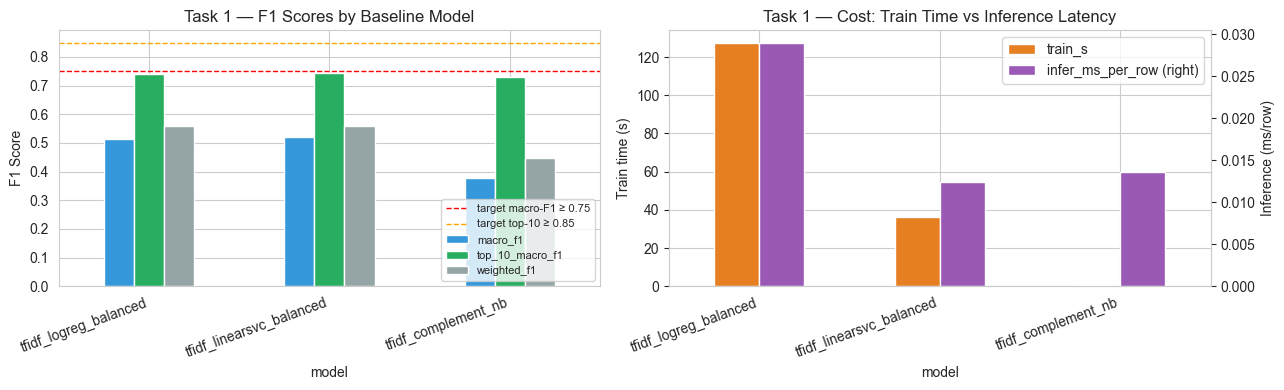

In [11]:
results = [result_lr, result_svm, result_cnb]

comparison = pd.DataFrame([
    {
        'model':            r['name'],
        'accuracy':         r['metrics']['accuracy'],
        'macro_f1':         r['metrics']['macro_f1'],
        'weighted_f1':      r['metrics']['weighted_f1'],
        'top_10_macro_f1':  r['metrics']['top_10_macro_f1'],
        'train_s':          r['train_time'],
        'infer_ms_per_row': r['infer_ms'],
    }
    for r in results
])

print('=' * 80)
print(f'  TASK {TASK} — BASELINE COMPARISON')
print('=' * 80)
print(comparison.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print('=' * 80)

# Identify best by macro-F1
best = comparison.loc[comparison['macro_f1'].idxmax(), 'model']
print(f'\nBest by macro-F1: {best}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
comparison.set_index('model')[['macro_f1','top_10_macro_f1','weighted_f1']].plot(
    kind='bar', ax=axes[0], color=['#3498db','#27ae60','#95a5a6'],
)
axes[0].axhline(0.75, color='red', linestyle='--', lw=1, label='target macro-F1 ≥ 0.75')
axes[0].axhline(0.85, color='orange', linestyle='--', lw=1, label='target top-10 ≥ 0.85')
axes[0].set_title(f'Task {TASK} — F1 Scores by Baseline Model')
axes[0].set_ylabel('F1 Score')
axes[0].legend(loc='lower right', fontsize=8)
axes[0].set_xticklabels(comparison['model'], rotation=20, ha='right')

comparison.set_index('model')[['train_s','infer_ms_per_row']].plot(
    kind='bar', ax=axes[1], color=['#e67e22','#9b59b6'], secondary_y='infer_ms_per_row',
)
axes[1].set_title(f'Task {TASK} — Cost: Train Time vs Inference Latency')
axes[1].set_ylabel('Train time (s)')
axes[1].right_ax.set_ylabel('Inference (ms/row)')
axes[1].set_xticklabels(comparison['model'], rotation=20, ha='right')

plt.tight_layout()
plt.show()

---
## 10. Hierarchical Evaluation — F1 at Every Level

For the best baseline model, compute F1 at every level of the GECS hierarchy. Even if
SubIndustry / Industry F1 is below target, F1 at higher levels (Sector, Super Sector)
is usually much higher and tells a useful story about *where* the model is right vs wrong.

Hierarchical evaluation for: tfidf_linearsvc_balanced

         level  accuracy  macro_f1  weighted_f1  n_classes
      industry    0.5702    0.5207       0.5598        145
industry_group    0.6613    0.6207       0.6574         55
        sector    0.7727    0.7715       0.7724         11
  super_sector    0.8476    0.8463       0.8477          3


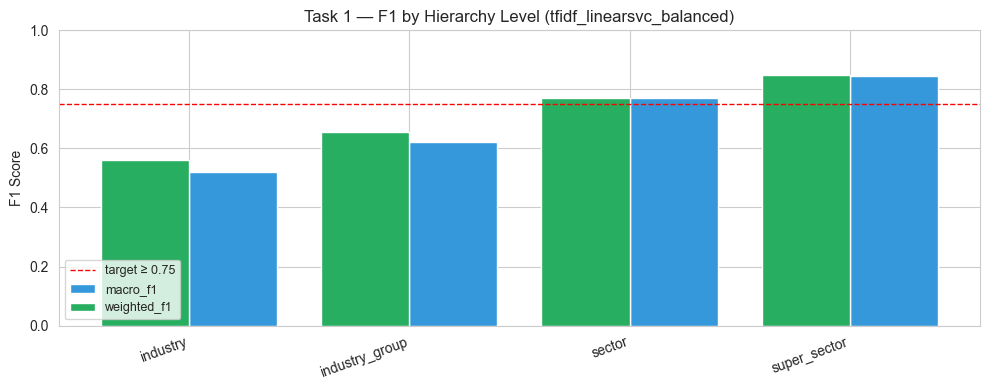

In [12]:
best_result = max(results, key=lambda r: r['metrics']['macro_f1'])
print(f'Hierarchical evaluation for: {best_result["name"]}\n')

if TASK == 1:
    rollups = gecs_rollups_task1()
else:
    rollups = gecs_rollups_task2()

hier_df = hierarchical_evaluate(y_test, best_result['y_pred'], rollups)
print(hier_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
levels = hier_df['level'].tolist()
ax.bar(levels, hier_df['macro_f1'],     color='#3498db', label='macro_f1',    width=0.4, align='edge')
ax.bar(levels, hier_df['weighted_f1'],  color='#27ae60', label='weighted_f1', width=-0.4, align='edge')
ax.axhline(0.75, color='red', linestyle='--', lw=1, label='target ≥ 0.75')
ax.set_ylim(0, 1)
ax.set_title(f'Task {TASK} — F1 by Hierarchy Level ({best_result["name"]})')
ax.set_ylabel('F1 Score')
ax.legend(loc='lower left', fontsize=9)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

---
## 11. Confidence-Thresholded Fallback (Task 2 only)

For Task 2, sweep the confidence threshold and find the operating point that maximizes
overall (mixed) macro-F1.

**Strategy:** for each test row, take the model's top SubIndustry prediction. If
`max(p) >= threshold`, output the SubIndustry. Otherwise, roll up to **Industry Group**
(5-digit truncation) — the most stable hierarchy level per the EDA.

In [13]:
if TASK == 2 and best_result['y_proba'] is not None:
    rollup_to_ig = lambda x: str(x)[:5]   # SubIndustry → Industry Group
    truth_rollup = lambda x: str(x)[:5]   # apply same to y_true for fair comparison

    thresholds = np.arange(0.30, 0.91, 0.05)
    rows = []
    for t in thresholds:
        r = evaluate_with_fallback(
            y_true           = y_test,
            y_proba          = best_result['y_proba'],
            classes          = best_result['classes'],
            threshold        = float(t),
            rollup_fn        = rollup_to_ig,
            rollup_y_true_fn = truth_rollup,
            k                = 10,
        )
        rows.append(r)

    sweep = pd.DataFrame(rows)
    print(sweep.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

    # Pick the threshold maximizing overall_macro_f1
    best_t_idx = sweep['overall_macro_f1'].idxmax()
    best_t     = sweep.loc[best_t_idx, 'threshold']
    print(f'\nBest threshold: {best_t:.2f}')
    print(f'  Overall macro-F1 (mixed)    : {sweep.loc[best_t_idx, "overall_macro_f1"]:.4f}')
    print(f'  Confident-only macro-F1     : {sweep.loc[best_t_idx, "confident_macro_f1"]:.4f}')
    print(f'  Coverage                    : {sweep.loc[best_t_idx, "coverage"]*100:.1f}%')

    # Plot the trade-off
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(sweep['threshold'], sweep['overall_macro_f1'],
             marker='o', color='#3498db', label='overall macro-F1 (mixed)')
    ax1.plot(sweep['threshold'], sweep['confident_macro_f1'],
             marker='s', color='#27ae60', label='confident-only macro-F1')
    ax1.set_xlabel('Confidence threshold')
    ax1.set_ylabel('macro-F1')
    ax1.axhline(0.75, color='red', linestyle='--', lw=1, label='target ≥ 0.75')
    ax1.legend(loc='lower left')

    ax2 = ax1.twinx()
    ax2.plot(sweep['threshold'], sweep['coverage'] * 100,
             marker='^', color='#95a5a6', linestyle=':', label='coverage')
    ax2.set_ylabel('Coverage (%)')
    ax2.legend(loc='lower right')

    plt.title('Task 2 — Confidence Threshold Sweep (Hierarchical Fallback)')
    plt.tight_layout()
    plt.show()
else:
    print('Hierarchical fallback skipped — Task 1 (no fallback needed) or no probabilities available.')

Hierarchical fallback skipped — Task 1 (no fallback needed) or no probabilities available.


---
## 12. Per-Class F1 — Where Is the Model Failing?

Look at the bottom-20 classes by F1 to identify which industries / sub-industries the
baseline can't handle. This is the input to the error analysis section of the final report.

In [14]:
pcf1 = per_class_f1(y_test, best_result['y_pred'])

print('Top 10 classes by F1:')
print(pcf1.head(10).to_string(index=False, float_format=lambda x: f'{x:.3f}'))

print('\nBottom 10 classes by F1 (with support ≥ 5):')
poor = pcf1[pcf1['support'] >= 5].sort_values('f1').head(10)
print(poor.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

# Save to disk
pcf1_out = RESULTS_DIR / f'task{TASK}_baseline_per_class_f1.csv'
pcf1.to_csv(pcf1_out, index=False)
print(f'\nSaved: {pcf1_out}')

Top 10 classes by F1:
   class  precision  recall    f1  support
10310010      0.689   0.780 0.732  472.000
31030010      0.353   0.322 0.337  472.000
10320020      0.842   0.850 0.846  433.000
10410020      0.443   0.532 0.483  327.000
31040010      0.504   0.646 0.566  271.000
31070020      0.473   0.552 0.509  250.000
31110020      0.519   0.608 0.560  245.000
20525040      0.586   0.789 0.673  237.000
20620020      0.654   0.750 0.699  232.000
20610010      0.779   0.798 0.789  208.000

Bottom 10 classes by F1 (with support ≥ 5):
   class  precision  recall    f1  support
10410030      0.000   0.000 0.000   55.000
10160010      0.000   0.000 0.000    8.000
10150050      0.000   0.000 0.000   11.000
20710010      0.000   0.000 0.000   15.000
20550020      0.429   0.067 0.115   45.000
30910030      0.250   0.091 0.133   11.000
10350020      0.241   0.108 0.149   65.000
31020020      0.571   0.093 0.160   43.000
20720040      0.167   0.179 0.172   28.000
10340040      0.250   0.143 0.

---
## 12b. Confusion Analysis — What Are the F1=0 Classes Confused With?

Per-class output shows several classes scoring exactly 0 despite having decent support.
Three causes are possible: (a) confused with an *adjacent* sister class in the same sector
(fixable via hierarchical fallback), (b) confused with a *generic catch-all* like
`31030010` (suggests model can't disambiguate generic-language segments), (c) genuinely
unclassifiable (very short or generic text).

This cell runs through each F1=0 class and shows where the model sent its predictions
instead. Output goes into the error-analysis section of the final report.

In [15]:
# Find F1=0 classes with non-trivial support
zero_f1 = pcf1[(pcf1['f1'] == 0) & (pcf1['support'] >= 10)].copy()
print(f'F1=0 classes with support >= 10: {len(zero_f1)}\n')

# Cast pred/true to a Series for easy slicing
y_test_s = pd.Series(y_test)
y_pred_s = pd.Series(best_result['y_pred'])

confusion_rows = []
for _, row in zero_f1.iterrows():
    cls = str(row['class'])
    mask = (y_test_s == cls).values
    if mask.sum() == 0:
        continue
    # What did the model predict instead?
    confused_with = y_pred_s[mask].value_counts().head(3)

    # Same-sector check (first 3 digits)
    actual_sector = cls[:3] if len(cls) >= 3 else ''
    same_sector_pct = (y_pred_s[mask].astype(str).str[:3] == actual_sector).mean() * 100

    confusion_rows.append({
        'true_class':       cls,
        'support':          int(mask.sum()),
        'pred_top1':        confused_with.index[0] if len(confused_with) > 0 else '',
        'pred_top1_count':  int(confused_with.iloc[0]) if len(confused_with) > 0 else 0,
        'pred_top2':        confused_with.index[1] if len(confused_with) > 1 else '',
        'pred_top3':        confused_with.index[2] if len(confused_with) > 2 else '',
        'same_sector_pct':  round(same_sector_pct, 1),
    })

confusion_df = pd.DataFrame(confusion_rows)
print(confusion_df.to_string(index=False))

if len(confusion_df) > 0:
    print(f'\nMean same-sector confusion: {confusion_df["same_sector_pct"].mean():.1f}%')
    print('  → if >50%, hierarchical fallback to sector level recovers most errors')
    print('  → if <50%, model is confused across sectors — needs better text features')

    out_path = RESULTS_DIR / f'task{TASK}_baseline_confusion_analysis.csv'
    confusion_df.to_csv(out_path, index=False)
    print(f'\nSaved: {out_path}')

F1=0 classes with support >= 10: 3

true_class  support pred_top1  pred_top1_count pred_top2 pred_top3  same_sector_pct
  10410030       55  10410010               23  10410020  31040010             78.2
  20710010       15  20720020                5  20710020  31070020             60.0
  10150050       11  10150030                6  10150040                      100.0

Mean same-sector confusion: 79.4%
  → if >50%, hierarchical fallback to sector level recovers most errors
  → if <50%, model is confused across sectors — needs better text features

Saved: ../results/task1_baseline_confusion_analysis.csv


---
## 13. Experiment Log

Every model trained appended to `results/experiments.csv`. After running this notebook
for both Task 1 and Task 2 you'll have 6 rows. After running `04_modeling.ipynb` you'll
have more. After `05_finetuned.ipynb`, more. The final report builds tables off this CSV.

In [16]:
from src.utils.experiments import load_experiments

exp_log = load_experiments(RESULTS_PATH)

# Deduplicate — keep the LATEST run per (task, model) pair so re-runs don't
# pollute the comparison tables in the report.
exp_log_deduped = (
    exp_log
    .sort_values('timestamp')
    .drop_duplicates(subset=['task', 'model_name'], keep='last')
    .reset_index(drop=True)
)

print(f'Total rows in log : {len(exp_log)}')
print(f'After dedup       : {len(exp_log_deduped)}\n')

display_cols = ['timestamp','task','model_name','macro_f1','top_10_macro_f1',
                'train_time_s','inference_ms_per_row']
print(exp_log_deduped[display_cols].to_string(index=False))

Total rows in log : 38
After dedup       : 9

          timestamp  task               model_name  macro_f1  top_10_macro_f1  train_time_s  inference_ms_per_row
2026-04-27T04:25:28     2    tfidf_logreg_balanced  0.324932         0.769313     22.865088              0.015818
2026-04-27T04:25:33     2 tfidf_linearsvc_balanced  0.305299         0.571321      4.510238              0.006436
2026-04-27T04:25:33     2      tfidf_complement_nb  0.256877         0.761595      0.392289              0.008373
2026-04-27T06:35:36     1    embed_logreg_balanced  0.411842         0.552069      8.576212              0.001016
2026-04-27T16:00:43     1  embed_lightgbm_balanced  0.006374         0.004505     86.973102              0.120451
2026-04-27T19:24:27     1     distilbert_finetuned  0.613538         0.805640   7810.232769             18.272185
2026-04-27T19:29:31     1    tfidf_logreg_balanced  0.513348         0.739366    127.600399              0.029021
2026-04-27T19:30:08     1 tfidf_linearsvc_

---
## Summary & Next Steps

### What we learned
- TF-IDF baseline numbers are now logged for both tasks. These are the **floors** every
  subsequent model has to beat to justify its complexity.
- Hierarchical evaluation reveals where the model is right at higher abstraction levels
  even when SubIndustry F1 is mediocre — useful framing for the report.
- Task 2's confidence-threshold sweep gives us the production operating point.

### To run this notebook for both tasks
1. Set `TASK = 1`, Run All
2. Set `TASK = 2`, Run All
3. Inspect `results/experiments.csv` — should have 6 rows total.

### Next notebook: `04_modeling.ipynb`
- Generate sentence embeddings once (`bge-small-en` or `all-MiniLM-L6-v2`)
- Train **Logistic Regression** on embeddings — first model that "understands" semantics
- Train **LightGBM** on embeddings — your intuition gets its proper test here
- Same harness, same metrics, same experiment log → directly comparable to baseline.